# ARB Airdrop: Transfer-derived Balance Proxy Charts

## tl;dr

- **62.8%** of validated claim recipients had a zero transfer-derived ARB balance at seven days; **64.4%** did so at 30 days.
- The **75–100%** total-balance-to-claim bucket declined from **15.2%** at seven days to **9.2%** at 30 days.
- The capped, pre-claim-adjusted retained-claim proxy represented **21.7%** of claimed ARB at seven days and **14.2%** at 30 days.
- A total balance above 100% of the claim occurred for **1.8%** of recipients at seven days and **1.5%** at 30 days and can reflect additional ARB inflow.

These are transfer-derived balance proxies. They do not trace fungible claimed units or measure address activity, protocol engagement, human retention, or sales.

## Context & Methods

This companion notebook turns the validated claim-grain balance-proxy evidence into two portfolio-ready figures. It reads only small, versioned JSON artifacts in the data directory and does not query BigQuery or use the deferred symmetric behavior pipeline.

### Key Assumptions

- **Cohort grain:** one validated unique claim recipient per analytical row, 583,137 rows in total.
- **Cutoffs:** immediately before seven and 30 elapsed 24-hour periods after each exact claim.
- **Transfer-derived balance:** cumulative signed ARB Transfer legs for the claimant, with exact claim-event ordering and self-transfer netting.
- **Pre-claim adjustment:** positive pre-claim balance is removed before the retained-claim proxy is capped to the interval from zero to the claim amount.
- **Interpretation:** wallet-level balances can include ARB unrelated to the claim. These metrics cannot identify a person, protocol, intent, or specific fungible token units.

The visual specification is recorded in reports/retention_arb_balance_proxy_chart_contract.md.

In [1]:
from pathlib import Path
import hashlib
import json

import plotly.graph_objects as go
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (
            candidate
            / "data"
            / "retention_arb_balance_proxy_chart_data.json"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/retention_arb_balance_proxy_chart_data.json"
    )


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = (
    PROJECT_ROOT / "data" / "retention_arb_balance_proxy_chart_data.json"
)
QA_PATH = (
    PROJECT_ROOT / "data" / "retention_arb_balance_proxy_chart_data_qa.json"
)
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root: <repository root>")
print(f"Data source: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Project root: <repository root>
Data source: data\retention_arb_balance_proxy_chart_data.json


## Data

The chart input contains ten unique cutoff/bucket rows and two adjusted-proxy rows. The five ordered balance buckets are mutually exclusive and exhaustive at each cutoff. Every QA check and source hash must pass before a chart is rendered.

In [2]:
with DATA_PATH.open(encoding="utf-8") as file:
    chart_data = json.load(file)

with QA_PATH.open(encoding="utf-8") as file:
    chart_qa = json.load(file)

assert chart_data["status"] == "validated_chart_input"
assert chart_qa["status"] == "qa_passed"
assert all(chart_qa["checks"].values()), "Chart-data QA contains a failed check."
assert all(
    value == 0 for value in chart_qa["defect_counters"].values()
), "Chart-data QA contains a non-zero defect counter."

for source in chart_data["source_evidence"]:
    source_path = PROJECT_ROOT / source["path"]
    assert sha256(source_path) == source["sha256"], (
        f"Source hash mismatch: {source['path']}"
    )

bucket_rows = sorted(
    chart_data["balance_to_claim_bucket_distribution"],
    key=lambda row: (row["cutoff_order"], row["bucket_order"]),
)
adjusted_rows = sorted(
    chart_data["adjusted_retained_claim_proxy"],
    key=lambda row: row["cutoff_order"],
)
expected_bucket_order = chart_data["bucket_order"]

assert len(bucket_rows) == 10
assert len(
    {
        (row["cutoff_days"], row["balance_to_claim_bucket"])
        for row in bucket_rows
    }
) == 10
assert len(adjusted_rows) == 2

for cutoff_days in (7, 30):
    cutoff_rows = [
        row for row in bucket_rows if row["cutoff_days"] == cutoff_days
    ]
    assert len(cutoff_rows) == 5
    assert [
        row["balance_to_claim_bucket"] for row in cutoff_rows
    ] == expected_bucket_order
    assert sum(row["recipient_count"] for row in cutoff_rows) == 583_137
    assert abs(sum(row["recipient_share"] for row in cutoff_rows) - 1) <= 1e-12

{
    "bucket_rows": len(bucket_rows),
    "unique_cutoff_bucket_keys": len(
        {
            (row["cutoff_days"], row["balance_to_claim_bucket"])
            for row in bucket_rows
        }
    ),
    "recipients_per_cutoff": {
        cutoff: sum(
            row["recipient_count"]
            for row in bucket_rows
            if row["cutoff_days"] == cutoff
        )
        for cutoff in (7, 30)
    },
    "all_qa_checks_passed": True,
}

{'bucket_rows': 10,
 'unique_cutoff_bucket_keys': 10,
 'recipients_per_cutoff': {7: 583137, 30: 583137},
 'all_qa_checks_passed': True}

## Results

### 1. Total ARB balance relative to claim amount

The first figure compares the same five exhaustive total-balance-to-claim buckets at seven and 30 days. The denominator is the complete validated recipient cohort at each cutoff.

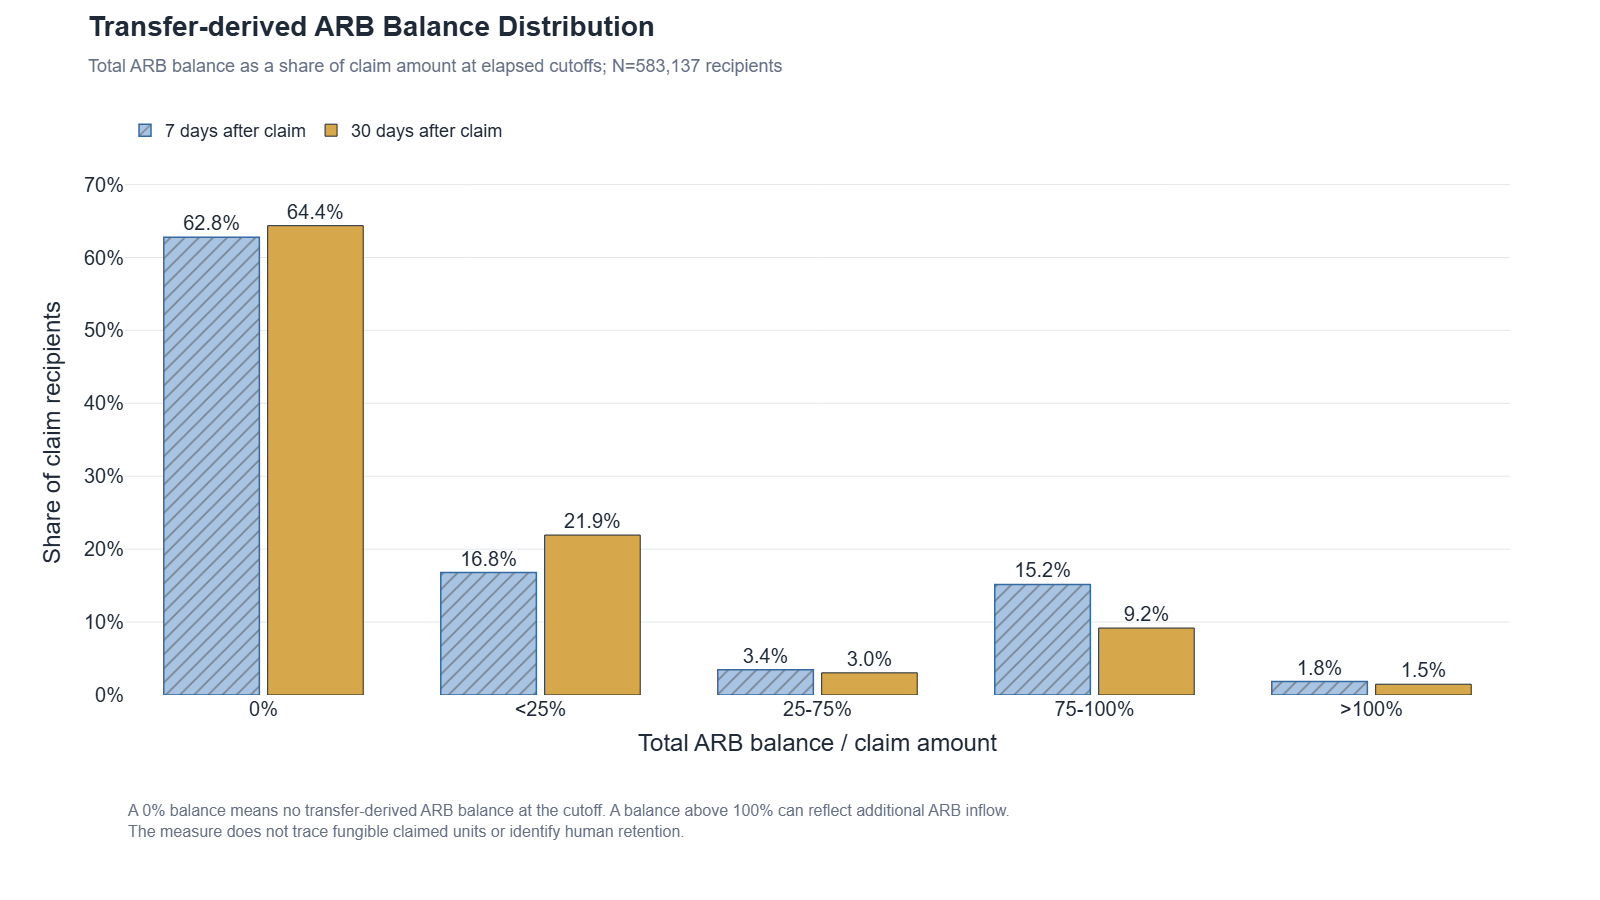

In [3]:
COLORS = {
    "blue": "#356AA0",
    "blue_light": "#A9C4E2",
    "gold": "#D6A84B",
    "ink": "#1F2937",
    "muted": "#667085",
    "grid": "#E5E7EB",
    "white": "#FFFFFF",
}


def apply_base_layout(
    fig,
    title,
    subtitle,
    width=1600,
    height=900,
    bottom_note=None,
):
    fig.update_layout(
        width=width,
        height=height,
        paper_bgcolor=COLORS["white"],
        plot_bgcolor=COLORS["white"],
        font=dict(family="Arial", size=20, color=COLORS["ink"]),
        title=dict(
            text=(
                f"<b>{title}</b><br>"
                f"<span style='font-size:18px;color:{COLORS['muted']}'>"
                f"{subtitle}</span>"
            ),
            x=0.055,
            xanchor="left",
            y=0.96,
            yanchor="top",
        ),
        margin=dict(l=125, r=90, t=170, b=205 if bottom_note else 105),
        showlegend=False,
    )
    if bottom_note:
        fig.add_annotation(
            x=0,
            y=-0.20,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            font=dict(size=16, color=COLORS["muted"]),
            text=bottom_note,
        )
    return fig


def export_and_display(fig, stem):
    png_path = FIGURES_DIR / f"{stem}.png"
    svg_path = FIGURES_DIR / f"{stem}.svg"
    fig.write_image(png_path, scale=1)
    fig.write_image(svg_path)
    display(Image(data=png_path.read_bytes(), width=1100))
    return png_path, svg_path


seven_day_rows = [row for row in bucket_rows if row["cutoff_days"] == 7]
thirty_day_rows = [row for row in bucket_rows if row["cutoff_days"] == 30]

distribution_fig = go.Figure()
distribution_fig.add_bar(
    name="7 days after claim",
    x=[row["balance_to_claim_bucket"] for row in seven_day_rows],
    y=[row["recipient_share"] for row in seven_day_rows],
    marker=dict(
        color=COLORS["blue_light"],
        line=dict(color=COLORS["blue"], width=1.5),
        pattern=dict(shape="/", solidity=0.18),
    ),
    text=[f"{row['recipient_share']:.1%}" for row in seven_day_rows],
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "%{x}<br>7 days: %{y:.1%} of recipients<extra></extra>"
    ),
)
distribution_fig.add_bar(
    name="30 days after claim",
    x=[row["balance_to_claim_bucket"] for row in thirty_day_rows],
    y=[row["recipient_share"] for row in thirty_day_rows],
    marker=dict(
        color=COLORS["gold"],
        line=dict(color=COLORS["ink"], width=1),
    ),
    text=[f"{row['recipient_share']:.1%}" for row in thirty_day_rows],
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "%{x}<br>30 days: %{y:.1%} of recipients<extra></extra>"
    ),
)
apply_base_layout(
    distribution_fig,
    "Transfer-derived ARB Balance Distribution",
    "Total ARB balance as a share of claim amount at elapsed cutoffs; N=583,137 recipients",
    bottom_note=(
        "A 0% balance means no transfer-derived ARB balance at the cutoff. "
        "A balance above 100% can reflect additional ARB inflow.<br>"
        "The measure does not trace fungible claimed units or identify human retention."
    ),
)
distribution_fig.update_layout(
    barmode="group",
    bargap=0.25,
    bargroupgap=0.08,
    showlegend=True,
    legend=dict(
        orientation="h",
        x=0,
        xanchor="left",
        y=1.04,
        yanchor="bottom",
        font=dict(size=18),
    ),
)
distribution_fig.update_yaxes(
    range=[0, 0.72],
    tickformat=".0%",
    title="Share of claim recipients",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
distribution_fig.update_xaxes(
    title="Total ARB balance / claim amount",
    showgrid=False,
)
_ = export_and_display(
    distribution_fig,
    "07_transfer_derived_arb_balance_proxy_distribution",
)

### 2. Capped, pre-claim-adjusted proxy

The second figure compares two discrete cutoffs. The measure removes positive pre-claim balance and caps each recipient's adjusted amount to the validated claim amount before aggregation.

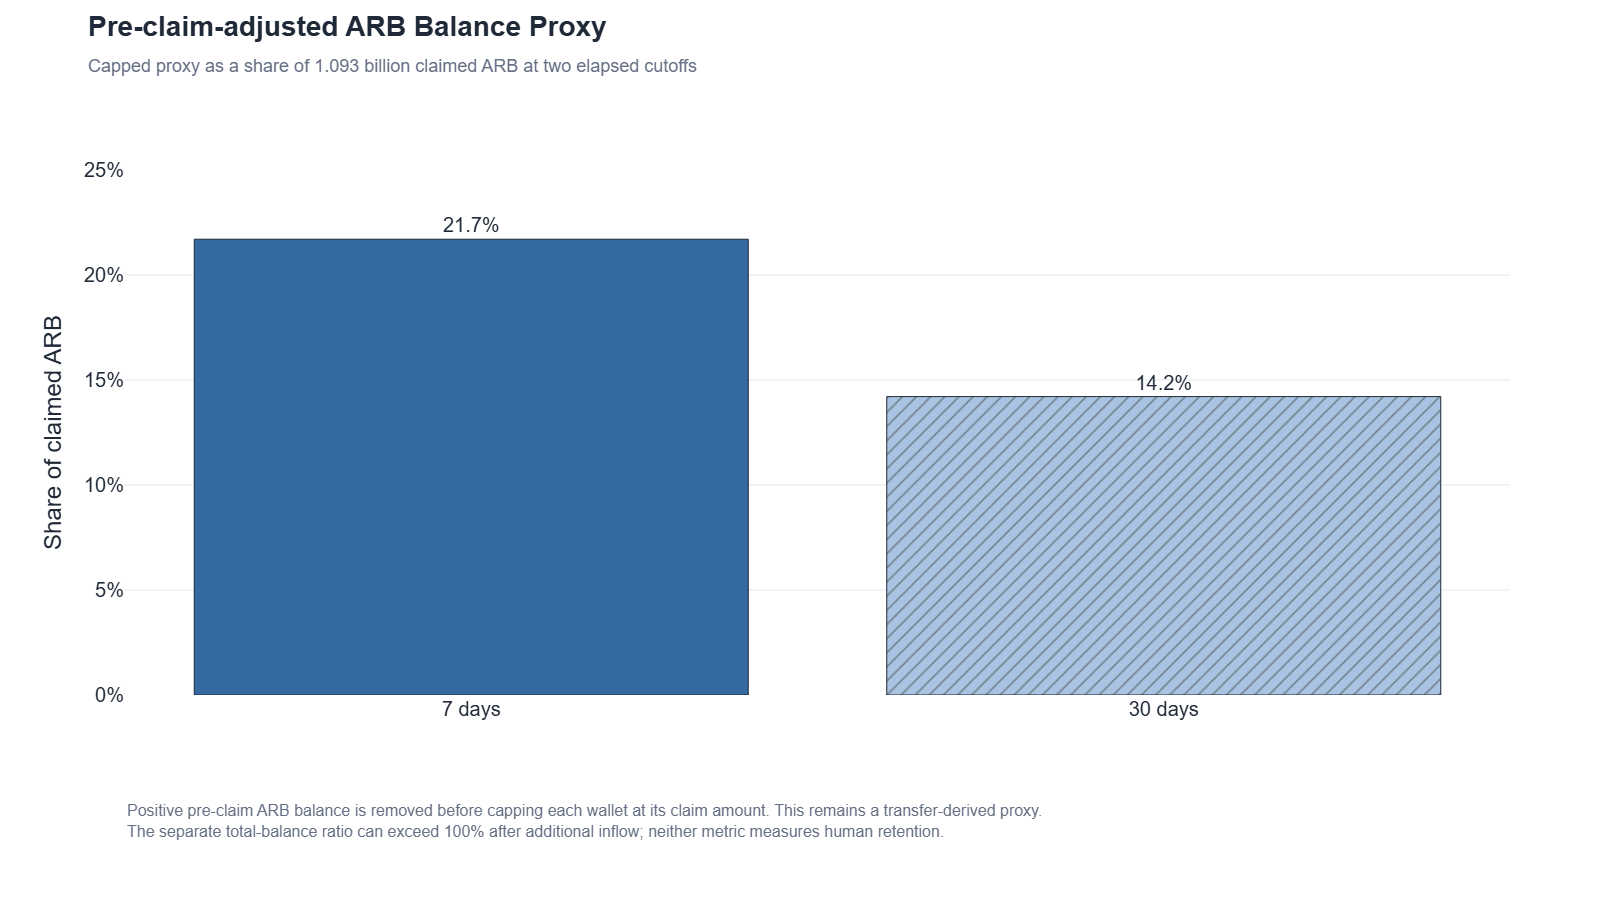

In [4]:
adjusted_fig = go.Figure(
    go.Bar(
        x=[f"{row['cutoff_days']} days" for row in adjusted_rows],
        y=[row["adjusted_retained_claim_proxy_share"] for row in adjusted_rows],
        marker=dict(
            color=[COLORS["blue"], COLORS["blue_light"]],
            line=dict(color=COLORS["ink"], width=1),
            pattern=dict(shape=["", "/"], solidity=0.18),
        ),
        text=[
            f"{row['adjusted_retained_claim_proxy_share']:.1%}"
            for row in adjusted_rows
        ],
        textposition="outside",
        cliponaxis=False,
        hovertemplate="%{x}<br>Adjusted proxy: %{y:.1%}<extra></extra>",
    )
)
apply_base_layout(
    adjusted_fig,
    "Pre-claim-adjusted ARB Balance Proxy",
    "Capped proxy as a share of 1.093 billion claimed ARB at two elapsed cutoffs",
    bottom_note=(
        "Positive pre-claim ARB balance is removed before capping each wallet at its claim amount. "
        "This remains a transfer-derived proxy.<br>"
        "The separate total-balance ratio can exceed 100% after additional inflow; "
        "neither metric measures human retention."
    ),
)
adjusted_fig.update_yaxes(
    range=[0, 0.25],
    tickformat=".0%",
    title="Share of claimed ARB",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
adjusted_fig.update_xaxes(title=None, showgrid=False)
_ = export_and_display(
    adjusted_fig,
    "08_adjusted_retained_claim_proxy",
)

## Takeaways

1. The zero-balance bucket was the majority at both cutoffs: 62.8% of recipients at seven days and 64.4% at 30 days.
2. The 75–100% bucket declined from 15.2% to 9.2%, while the below-25% non-zero bucket increased from 16.8% to 21.9%.
3. After removing positive pre-claim balance and capping the proxy per recipient, the cohort aggregate represented 21.7% of claimed ARB at seven days and 14.2% at 30 days.

### Interpretation limits

- Historical balance snapshots are unavailable; balances are reconstructed from validated ARB Transfer legs.
- ARB is fungible, so the analysis cannot identify which token units came from the airdrop.
- A total balance above 100% of claim amount can reflect later ARB inflow. It is not a contradiction or a retention rate above 100%.
- Token balance, address activity, protocol engagement, and human retention are separate concepts. These figures measure only the documented transfer-derived balance proxies.